# Spam Email Classifier

## Objective

The objective of this project is to build a Machine Learning model that classifies email or SMS messages as **Spam** or **Ham (Not Spam)** using Natural Language Processing (NLP) techniques.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- NLTK
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
import pandas as pd

print(pd.__version__)

3.0.5


In [3]:
df = pd.read_csv("../data/spam.csv", encoding="latin-1")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
# Display first 5 rows
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [6]:

print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')


#data cleaning

In [7]:
# ==========================================
# Remove Unnecessary Columns
# ==========================================

# Keep only the first two columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'message']

# Display first five rows
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [9]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [10]:
print("Number of duplicated rows:", df.duplicated().sum())


Number of duplicated rows: 403


In [11]:
df=df.drop_duplicates()

In [12]:
print("new shape:",df.shape)

new shape: (5169, 2)


In [13]:
df["label"].value_counts() 

label
ham     4516
spam     653
Name: count, dtype: int64

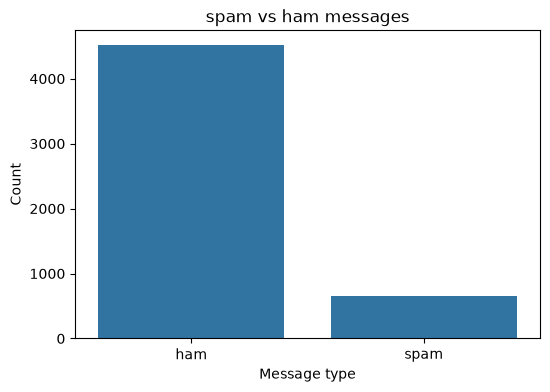

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("spam vs ham messages")
plt.xlabel("Message type")
plt.ylabel("Count")
plt.show()

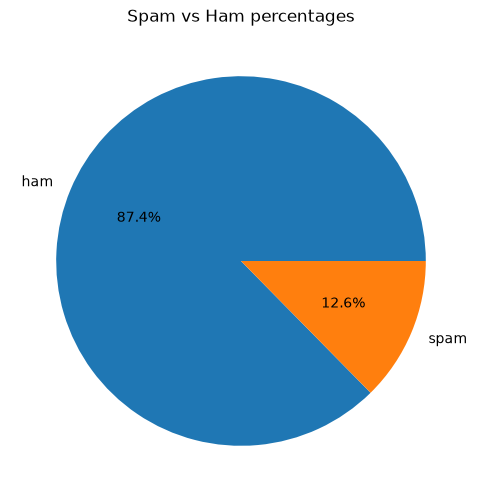

In [15]:
df["label"].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6))
plt.title("Spam vs Ham percentages")
plt.ylabel("")
plt.show() 

# Text Feature Engineering and Preprocessing

In this section, we analyze message length and prepare the text data
for machine learning.

In [16]:
df["message_length"] = df["message"].apply(len)

df[["label", "message", "message_length"]].head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


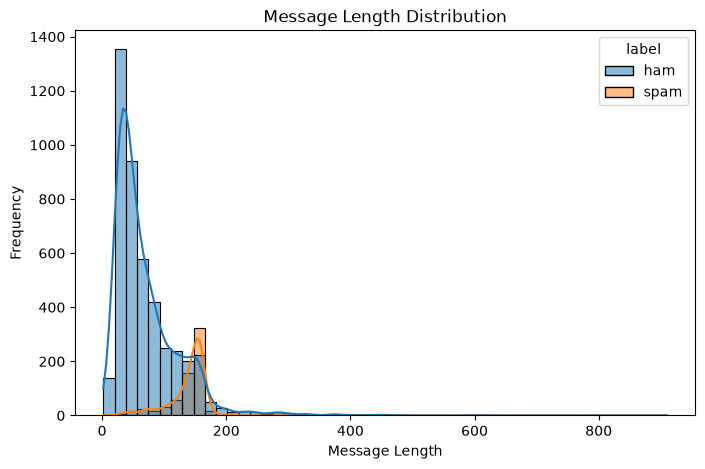

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=50,
    kde=True
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")

plt.show()

In [18]:
average_length = df.groupby("label")["message_length"].mean()

print("Average message length:")
print(average_length)

Average message length:
label
ham      70.459256
spam    137.891271
Name: message_length, dtype: float64


In [19]:
df["word_count"] = df["message"].apply(lambda x: len(x.split()))

df[["label", "message", "word_count"]].head()

,label,message,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",20
1,ham,Ok lar... Joking wif u oni...,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28
3,ham,U dun say so early hor... U c already then say...,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",13


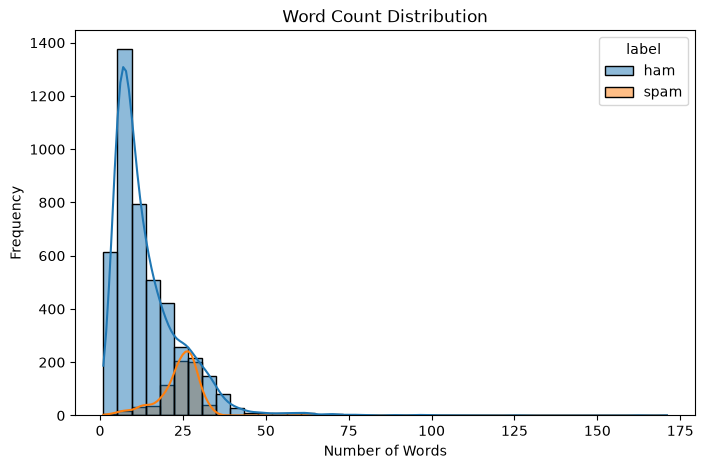

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="word_count",
    hue="label",
    bins=40,
    kde=True
)

plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [21]:
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to C:\Users\Noorul
[nltk_data]     Haq\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()


def clean_text(text):
    """
    Clean and preprocess a text message.

    Steps:
    1. Convert text to lowercase
    2. Remove URLs
    3. Remove punctuation
    4. Remove numbers
    5. Tokenize
    6. Remove stopwords
    7. Apply stemming
    """

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Tokenize
    words = text.split()

    # Remove stopwords and apply stemming
    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    # Join words back together
    return " ".join(words)

In [23]:
sample_message = df["message"].iloc[0]

print("Original message:")
print(sample_message)

print("\nCleaned message:")
print(clean_text(sample_message))

Original message:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Cleaned message:
go jurong point crazi avail bugi n great world la e buffet cine got amor wat


In [24]:
df["cleaned_message"] = df["message"].apply(clean_text)

df[["label", "message", "cleaned_message"]].head()

,label,message,cleaned_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


In [25]:
df["label_encoded"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print(df["label_encoded"].value_counts())

label_encoded
0    4516
1     653
Name: count, dtype: int64


In [26]:
from sklearn.model_selection import train_test_split

X = df["cleaned_message"]
y = df["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [27]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(
    max_features=5000
)

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

print("Training feature shape:", X_train_count.shape)
print("Testing feature shape:", X_test_count.shape)

Training feature shape: (4135, 5000)
Testing feature shape: (1034, 5000)


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

Training feature shape: (4135, 5000)
Testing feature shape: (1034, 5000)


In [29]:
# ==========================================
# Machine Learning Models
# ==========================================

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [30]:
# ==========================================
# Naive Bayes
# ==========================================

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes Results")
print("-------------------")
print("Accuracy :", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred))
print("Recall   :", recall_score(y_test, nb_pred))
print("F1 Score :", f1_score(y_test, nb_pred))

Naive Bayes Results
-------------------
Accuracy : 0.9661508704061895
Precision: 0.9897959183673469
Recall   : 0.7404580152671756
F1 Score : 0.8471615720524017


In [31]:
# ==========================================
# Logistic Regression
# ==========================================

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

Logistic Regression Results
---------------------------
Accuracy : 0.9593810444874274
Precision: 1.0
Recall   : 0.6793893129770993
F1 Score : 0.8090909090909091


In [32]:
# ==========================================
# Linear SVM
# ==========================================

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print("SVM Results")
print("-----------")
print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall   :", recall_score(y_test, svm_pred))
print("F1 Score :", f1_score(y_test, svm_pred))

SVM Results
-----------
Accuracy : 0.9796905222437138
Precision: 0.9741379310344828
Recall   : 0.8625954198473282
F1 Score : 0.9149797570850202


In [33]:
# ==========================================
# Model Comparison
# ==========================================

results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Precision": [
        precision_score(y_test, nb_pred),
        precision_score(y_test, lr_pred),
        precision_score(y_test, svm_pred)
    ],
    "Recall": [
        recall_score(y_test, nb_pred),
        recall_score(y_test, lr_pred),
        recall_score(y_test, svm_pred)
    ],
    "F1 Score": [
        f1_score(y_test, nb_pred),
        f1_score(y_test, lr_pred),
        f1_score(y_test, svm_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.966151,0.989796,0.740458,0.847162
1,Logistic Regression,0.959381,1.000000,0.679389,0.809091
2,Linear SVM,0.979691,0.974138,0.862595,0.914980


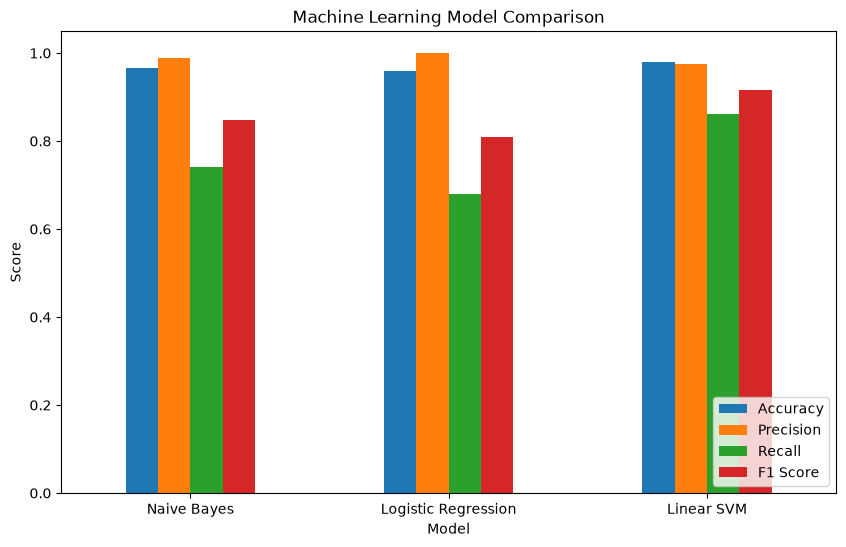

In [34]:
# ==========================================
# Model Performance Comparison
# ==========================================

results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.savefig(
    "../outputs/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [35]:
# ==========================================
# Select Best Model
# ==========================================

best_model_name = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Linear SVM


In [36]:

# ==========================================
# Select Best Model
# ==========================================

best_model_name = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Linear SVM


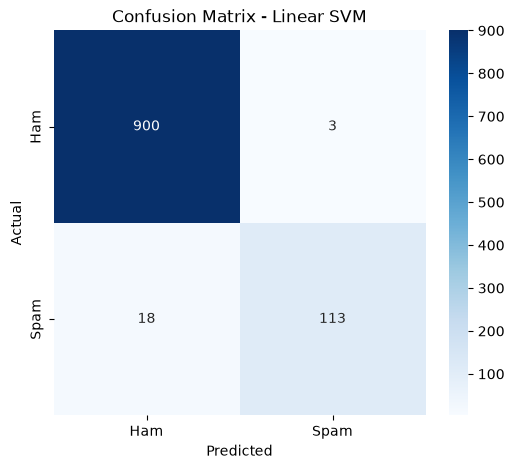

In [37]:
# ==========================================
# Confusion Matrix
# ==========================================

predictions = {
    "Naive Bayes": nb_pred,
    "Logistic Regression": lr_pred,
    "Linear SVM": svm_pred
}

best_pred = predictions[best_model_name]

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../outputs/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


In [38]:
# ==========================================
# Classification Report
# ==========================================

print(f"Classification Report - {best_model_name}")
print("=" * 50)

print(
    classification_report(
        y_test,
        best_pred,
        target_names=["Ham", "Spam"]
    )
)

Classification Report - Linear SVM
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.97      0.86      0.91       131

    accuracy                           0.98      1034
   macro avg       0.98      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



In [39]:
# ==========================================
# Save Final Model and Vectorizer
# ==========================================

import joblib
import os

os.makedirs("../models", exist_ok=True)

# Select the actual trained best model
best_models = {
    "Naive Bayes": nb_model,
    "Logistic Regression": lr_model,
    "Linear SVM": svm_model
}

best_model = best_models[best_model_name]

joblib.dump(best_model, "../models/spam_classifier.pkl")
joblib.dump(tfidf_vectorizer, "../models/tfidf_vectorizer.pkl")

print("Model saved successfully.")
print("Vectorizer saved successfully.")

Model saved successfully.
Vectorizer saved successfully.


In [40]:
# ==========================================
# Spam Prediction Function
# ==========================================

def predict_message(message):
    """
    Predict whether a message is Spam or Ham.
    """

    cleaned = clean_text(message)

    transformed = tfidf_vectorizer.transform([cleaned])

    prediction = best_model.predict(transformed)[0]

    if prediction == 1:
        return "Spam"
    else:
        return "Ham"

In [41]:
# ==========================================
# Test New Messages
# ==========================================

test_messages = [
    "Congratulations! You have won a free iPhone. Click now to claim your prize!",
    "Hi, can we meet tomorrow at 10 AM?",
    "URGENT! You have won 10000 dollars. Call now to claim your reward.",
    "Hey, I will reach home by 7 PM."
]

for message in test_messages:
    print("Message:", message)
    print("Prediction:", predict_message(message))
    print("-" * 70)

Message: Congratulations! You have won a free iPhone. Click now to claim your prize!
Prediction: Spam
----------------------------------------------------------------------
Message: Hi, can we meet tomorrow at 10 AM?
Prediction: Ham
----------------------------------------------------------------------
Message: URGENT! You have won 10000 dollars. Call now to claim your reward.
Prediction: Spam
----------------------------------------------------------------------
Message: Hey, I will reach home by 7 PM.
Prediction: Ham
----------------------------------------------------------------------


In [42]:
# ==========================================
# Final Model Performance
# ==========================================

final_accuracy = accuracy_score(y_test, best_pred)
final_precision = precision_score(y_test, best_pred)
final_recall = recall_score(y_test, best_pred)
final_f1 = f1_score(y_test, best_pred)

print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)

print("Best Model :", best_model_name)
print(f"Accuracy   : {final_accuracy:.4f}")
print(f"Precision  : {final_precision:.4f}")
print(f"Recall     : {final_recall:.4f}")
print(f"F1 Score   : {final_f1:.4f}")

print("=" * 50)

FINAL MODEL PERFORMANCE
Best Model : Linear SVM
Accuracy   : 0.9797
Precision  : 0.9741
Recall     : 0.8626
F1 Score   : 0.9150


In [43]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/spam_classifier.pkl")
joblib.dump(tfidf_vectorizer, "../models/tfidf_vectorizer.pkl")

print("Model saved successfully.")
print("Vectorizer saved successfully.")

Model saved successfully.
Vectorizer saved successfully.


In [44]:
def predict_message(message):
    cleaned = clean_text(message)
    transformed = tfidf_vectorizer.transform([cleaned])
    prediction = best_model.predict(transformed)[0]

    if prediction == 1:
        return "Spam"
    else:
        return "Ham"

In [45]:
test_messages = [
    "Congratulations! You have won a free iPhone. Click now to claim your prize!",
    "Hi, can we meet tomorrow at 10 AM?",
    "URGENT! You have won 10000 dollars. Call now to claim your reward.",
    "Hey, I will reach home by 7 PM."
]

for message in test_messages:
    print("Message:", message)
    print("Prediction:", predict_message(message))
    print("-" * 70)

Message: Congratulations! You have won a free iPhone. Click now to claim your prize!
Prediction: Spam
----------------------------------------------------------------------
Message: Hi, can we meet tomorrow at 10 AM?
Prediction: Ham
----------------------------------------------------------------------
Message: URGENT! You have won 10000 dollars. Call now to claim your reward.
Prediction: Spam
----------------------------------------------------------------------
Message: Hey, I will reach home by 7 PM.
Prediction: Ham
----------------------------------------------------------------------
